Month
1    15.31
Name: Temperature (°C), dtype: float64


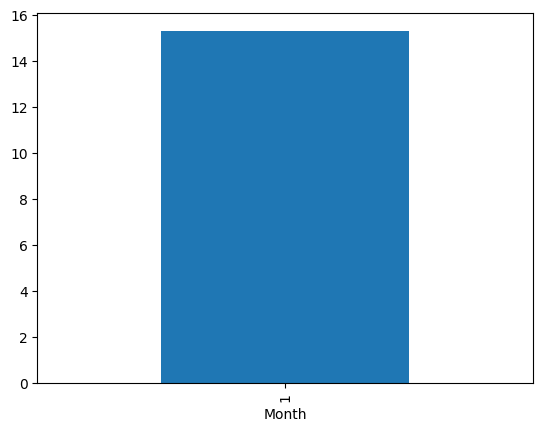

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create dataset
data = {
    'Date': ['01-01-2025','02-01-2025','03-01-2025','04-01-2025','05-01-2025',
             '06-01-2025','07-01-2025','08-01-2025','09-01-2025','10-01-2025'],
    'Temperature (°C)': [15.2,16.8,14.5,13,17.6,18.1,16.2,12.4,13.8,15.5],
    'Humidity (%)': [80,75,85,90,70,65,78,88,83,79],
    'Wind Speed (km/h)': [10.5,8,12,15.2,7.4,6,9.1,14.3,11.5,10],
    'Rainfall (mm)': [0,0,1.2,5.4,0,0,0.5,2.1,0,0]
}

df = pd.DataFrame(data)

# Convert date
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# a. Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Features
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month

X = df[['Day','Humidity (%)','Wind Speed (km/h)','Rainfall (mm)']].values
y = df['Temperature (°C)'].values

# Linear Regression (NumPy)
X = np.c_[np.ones(len(X)), X]
theta = np.linalg.inv(X.T @ X) @ X.T @ y
df['Predicted'] = X @ theta

# b. Monthly average
monthly_avg = df.groupby('Month')['Temperature (°C)'].mean()
print(monthly_avg)

# c. Plot
monthly_avg.plot(kind='bar')
plt.show()
